# A logikai tömbök használata NumPy-ben

## elmélet és alkalmazás kinematika példákra

### Fizika informatikusoknak géptermi gyakorlat

### v 2026/0.9

In [1]:
import numpy as np    
import matplotlib.pyplot as plt
%matplotlib inline    

## Alap matematikai rutinok

Nemcsak kinematikára jók, ezért az általános $f(x)$ jelölést használjuk. Tehát $x$ nem a koordináta itt, hanem az általános független változó.


In [2]:
# Egy függvényt kiértékel a beadott tömb minden pontjában:

def calc_function(xx_tab, fun):
    return np.vectorize(fun)(xx_tab)

In [3]:
# 1D deriváló rutin a NumPy átlalánosabb eljárását meghívva.
# Ez középen centrális deriváltakat használ, a széleken egy speciális módszert, amit itt nem részletezünk.

def deriv(xx_tab, ff_tab):  
    return np.gradient(ff_tab, xx_tab, edge_order=2)

In [4]:
# Általános integráló rutin. 
# A trapézszabály alapján integrál, azaz a görbe alatti terület trapézok sorozatával közelíti.
# Erre sajnos nincs kész NumPy eljárás.

def integ(xx_tab, ff_tab, F0=0.0):
    intff=np.zeros_like(xx_tab)  # az integrál értékek tömbje
    intff[0]=F0
    intff[1:]=F0+np.cumsum((xx_tab[1:]-xx_tab[:-1])*(ff_tab[1:]+ff_tab[:-1])/2.0)   # cumsum= felösszegzés
    return intff 

## Néhány hely-idő függvény gyakorlásnak

In [5]:
# Paraméterezhetőség: ezek a függvények egy felparaméterezett függvénnyel térnek vissza.

# Egyenes vonalú egyenletes mozgás:
def make_xt_conts_acc(x0, v0, a):
    
    def fun(t):  
        return(x0+v0*t+(a/2)*t**2)
    
    return fun

# Harmonikus rezgés:
def make_xt_harm(A,omega,phi0=0.0):
    
    def fun(t):  
        return(A*np.sin(omega*t+phi0))
    
    return fun

# Csillapodó rezgés:
def make_xt_damped(A,omega,phi0=0.0,beta=0.0):
    
    def fun(t):  
        return(A*np.sin(omega*t+phi0)*np.exp(-beta*t))
    
    return fun
    

# Rossz hely-idő függvény szakadással:
def make_xt_jump(A,omega,phi0=0.0, t_jump=0.0, x_jump=0.0):
    
    def fun(t):    
        harm=make_xt_harm(A,omega,phi0)
        return harm(t)+x_jump*(t>t_jump)
        
    return fun
    
# Gauss-görbe:
def make_xt_Gauss(A, t0, sigma):
    
    def fun(t):
        return(A*np.exp(-(t-t0)**2/(2*sigma**2)))
    
    return fun

# Kinyit-becsuk
def make_xt_openclose(A, t0, width):
    
    def fun(t):
        return (A*(1.0-((t-t0)/width)**4)**3)*(np.abs(t-t0)<=width)
   
    return fun

# Bizonyos tulajdonságú mozgás-szakaszok keresése

A gyakorlatban érdekes kérdések:
   * Mikor ment a test 5 m/s-nál nagyobb sebességgel?
   * Milyen hosszú utat tett meg a test, miközben gyorsulása 0.5 m/s$^2$-nél kisebb volt?
   * ...
   
Megoldás: **NumPy tömbökön végzett logikai műveletekkel.**

Kulcsgondolatok: 
   * NumPy tömbön végzett logikai művelet egy True/False tömböt ad ki.
   * Matematikai műveletek esetén a True 1-gyé, a False 0-vá alakul.

In [6]:
# Alapötlet (nem kinematikával)

aa=np.array([-1.2, 2.5, 6.7, 5.4, 2.3, 0.0, -2.4, -3.4, 0.5, 2.3], np.float64)  # valami random tömb

In [7]:
print(aa)
# print(): lusta, csúnya, de gyors megoldás
print(aa<0.0)

[-1.2  2.5  6.7  5.4  2.3  0.  -2.4 -3.4  0.5  2.3]
[ True False False False False False  True  True False False]


Magyarázat: `aa<0.0` egy `aa`-val megegyező méretű tömb, ami térképszerűen mutatja, hol igaz a feltétel.

In [8]:
# kicsit szebben:
print("".join(f"{num:8}" for num in aa))
negmap=aa<0.0  # áttekinthetőség kedvéért külön változóba
print("".join(f"{str(bool):>8}" for bool in negmap))

    -1.2     2.5     6.7     5.4     2.3     0.0    -2.4    -3.4     0.5     2.3
    True   False   False   False   False   False    True    True   False   False


In [9]:
# A True/False tömb 1/0-vá alakítása kétféleképp:

negmap=aa<0.0   # eltesszük egy változóba
print(negmap)  # eredeti
print(negmap*1)  # matematikai művelet: True-ból 1-et, False-ból 0-t csinál
print(negmap.astype(int))  #  .astype(): típus átalakítás

[ True False False False False False  True  True False False]
[1 0 0 0 0 0 1 1 0 0]
[1 0 0 0 0 0 1 1 0 0]


Az így kapott számtömbbel sokminden kezdhető

In [10]:
# Nem 0 elemek megtalálása: np.argwhere()
print(np.argwhere(negmap))

[[0]
 [6]
 [7]]


In [11]:
# Ez feleslegesen sok dimenziós, hogy 2D, 3D, ... tömbökre is müködjön.
# Kivasalás: flatten()

print(np.argwhere(negmap).flatten())

[0 6 7]


Tehát a 0-s, 6-os és 7-es indexeknél volt negatív elem.

##  Alkalmazás kinematikára

Az `xt_work=make_xt_harm(2.0, 1.5, 0.0)`-kel létrehozott mozgás esetén:
   * Mikor halad a test 1 m/s-nál kisebb abszolút értékű sebességgel?
   * A fenti időszakaszok összesen mennyi ideig tartanak?
   * A fenti időszakaszok alatt mennyi utat tesz meg összesen?

A mozgást 0 és 10 s közt vizsgáljuk.

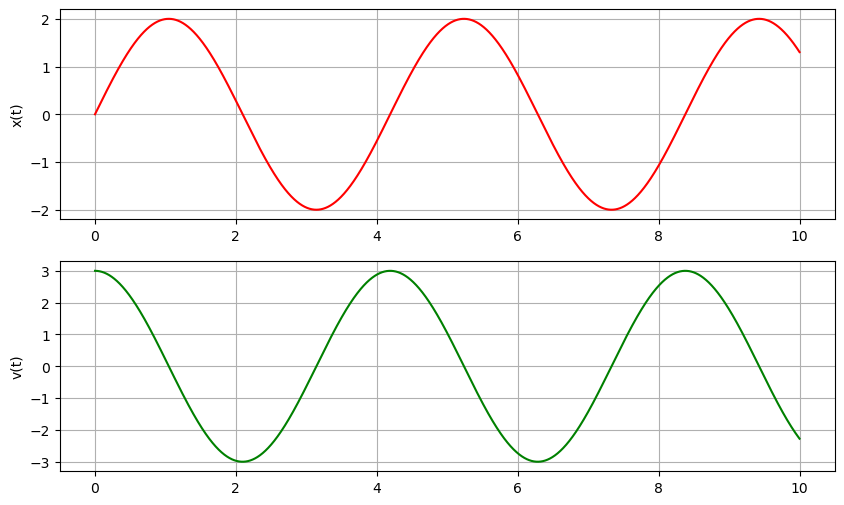

In [12]:
# alapok
t=np.arange(0, 10.0, 0.001)
xt_work=make_xt_harm(2.0, 1.5, 0.0)
x=calc_function(t,xt_work)
v=deriv(t, x)

# ellenőrzés: x(t) és v(t) plot-ja
fig=plt.figure(figsize=(10,6))  # nagyobb rajzméret
ax1=fig.add_subplot(211) # kettő rész-grafikon
ax2=fig.add_subplot(212)
ax1.set_ylabel("x(t)")
ax1.plot(t, x, color="red") # az elsőbe az x(t)
ax2.set_ylabel("v(t)")
ax2.plot(t, v, color="green") # a másodikba a v(t)
ax1.grid()
ax2.grid()

In [13]:
# Lassú mozgás térkép: |v|<1.0

map_slow=np.abs(v)<1.0

In [14]:
# Nem túl célszerű megoldás:
print(map_slow)

[False False False ... False False False]


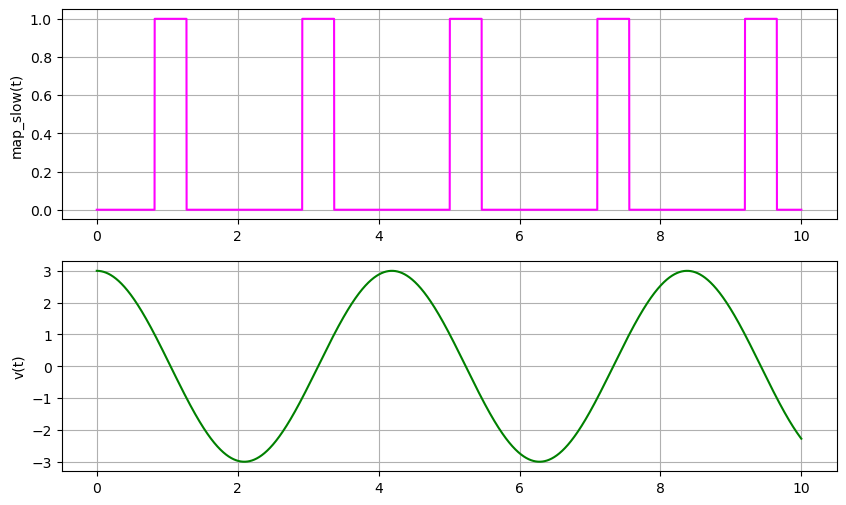

In [15]:
# Plottoljuk ki ennek 1/0-vá alakított verzióját:

fig=plt.figure(figsize=(10,6))  
ax1=fig.add_subplot(211) # kettő rész-grafikon
ax2=fig.add_subplot(212)
ax1.set_ylabel("map_slow(t)")
ax1.plot(t, map_slow*1.0, color="magenta") # az elsőbe a térkép: hol lassú a test?
ax2.set_ylabel("v(t)")
ax2.plot(t, v, color="green") # a másodikba a v(t)
ax1.grid()
ax2.grid()

In [16]:
# Mennyi idő telt el a lassú mozgással? A fenti map_slow integrálja a teljes intervallumra!

t_slow=integ(t, map_slow*1.0, 0.0)  # ez az adott időpontig lassú mozgással eltelt idő táblázata
total_t_slow=t_slow[-1]   # utolsó elem: összes lassú idő
print(f"A lassú mozgással eltelt idő: {total_t_slow:.3f} s.")

A lassú mozgással eltelt idő: 2.265 s.


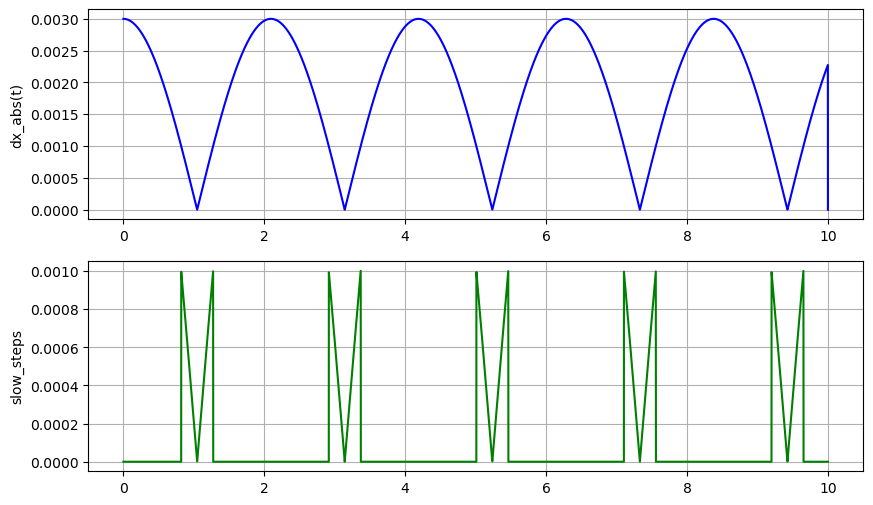

In [17]:
# Össz megtett út lassú mozgással: map_slow alatti elmozdulás-abszolútértékek összege

dx_abs=np.append(np.abs(np.diff(x)), [0])  # egyes szakaszokon történő út-szakaszok
slow_steps=dx_abs*map_slow        # ahol nem lassú az út, ott 0-val szorzunk

# 
fig=plt.figure(figsize=(10,6))  
ax1=fig.add_subplot(211) # kettő rész-grafikon
ax2=fig.add_subplot(212)
ax1.set_ylabel("dx_abs(t)")
ax1.plot(t, dx_abs, color="blue") # lépések nagysága
ax2.set_ylabel("slow_steps")
ax2.plot(t, slow_steps, color="green") # a másodikba csak a lassú szakaszok lépései
ax1.grid()
ax2.grid()

In [18]:
# lassan lépkedve megtett út: slow_steps összege

slow_distance=slow_steps.sum()
print(f"Lassan megtett össz út: {slow_distance:.3f} m.")


Lassan megtett össz út: 1.143 m.


## Többszörös egyenlőség kezelése

Korábban felmerült probléma: Egy kérdésnek lehet több megodása is. Pl. az előző rezgőmozgásnál mikor lesz a sebesség értéke közel 0? Ez a grafikon szerint 6 időpontban is bekövetkezik.

Fontos, hogy nem várhatjuk el, hogy a tömbben pont 0 (vagy más előírt érték) lépjen fel, hisz csak bizonyos időközönként mérünk.

Megoldás: keressük azokat az elemeket a `tab` tömbben, ahol az alábbiak _bármelyike_ teljesül:
   * `tab[i]==value`
   * `tab[i]<value<tab[i+1]`
   * `tab[i]>value>tab[i+1]`
Azaz vagy van pontos egyezés, vagy két táblázat-beli érték közé esik az érték.

In [19]:
# Hasznos segédrutin, amit sokszor viszontlátunk a félévben:
def arg_eq(tab, value):
    """Azon 'i' indexek táblázata, mely esetén tab[i]<=value<tab[i+1] vagy tab[i]>=value>tab[i+1]."""
    find_tab      =(tab==value)   # azok az elemek, ahol épp fennál az egyenlőség
    find_tab[:-1]|=(tab[:-1]<value) & (value<tab[1:]) # azok az elemek, ahol az elem kisebb, mint value, de az utána levő már nagyobb
    find_tab[:-1]|=(tab[:-1]>value) & (value>tab[1:]) # azok az elemek, ahol az elem nagyobb, mint value, de az utána levő már kisebb
      
    return np.argwhere(find_tab).flatten()

In [20]:
# Kipróbáljuk: Mikor lesz a sebesség épp 1.0 m/s?

print("A sebesség ezeknél az indexeknél lesz kb 1.0:\t",arg_eq(v,1.0))
print("A sebesség ezekben az időpontokban lesz kb 1.0:\t",t[arg_eq(v,1.0)])

A sebesség ezeknél az indexeknél lesz kb 1.0:	 [ 820 3368 5009 7556 9198]
A sebesség ezekben az időpontokban lesz kb 1.0:	 [0.82  3.368 5.009 7.556 9.198]


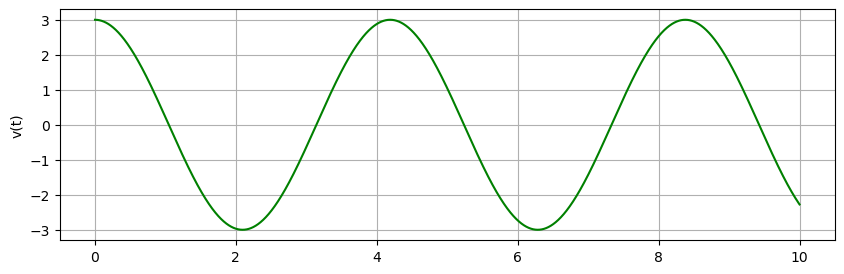

In [21]:
# Ellenőrizzük grafikonon:

fig=plt.figure(figsize=(10,3))  
ax1=fig.add_subplot(111) 
ax1.set_ylabel("v(t)")
ax1.plot(t, v, color="green")
ax1.grid()


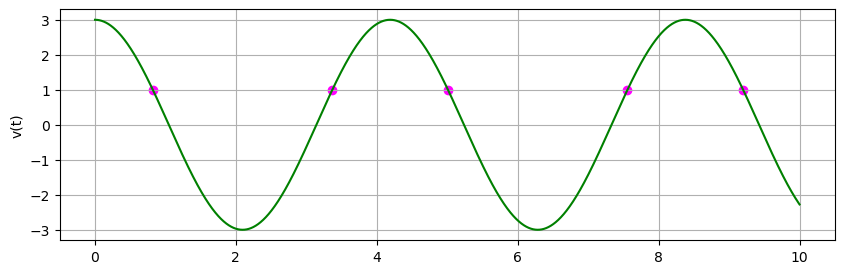

In [22]:
# Jelöljük is be a megoldásokat: scatter()

ind_v1=arg_eq(v, 1.0)
t_v1=t[ind_v1]

fig=plt.figure(figsize=(10,3))  
ax1=fig.add_subplot(111) 
ax1.set_ylabel("v(t)")
ax1.plot(t, v, color="green")
ax1.scatter(t_v1, v[ind_v1], color="magenta")  # ez rakja a pöttyöket a megfelelő helyre
ax1.grid()

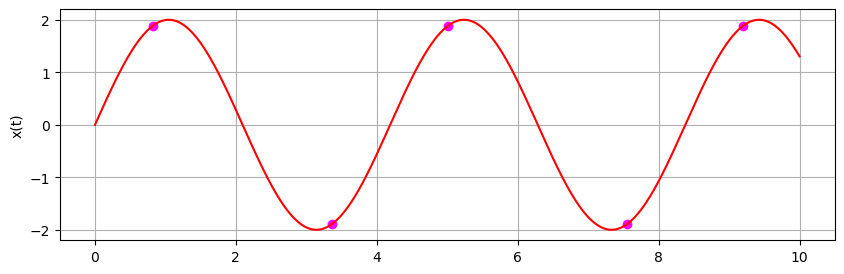

In [23]:
# Mekkora volt ezekben a pillanatokban x?

ind_v1=arg_eq(v, 1.0)
x_v1=x[ind_v1]

fig=plt.figure(figsize=(10,3))  
ax1=fig.add_subplot(111) 
ax1.set_ylabel("x(t)")
ax1.plot(t, x, color="red")
ax1.scatter(t_v1, x_v1, color="magenta")
ax1.grid()

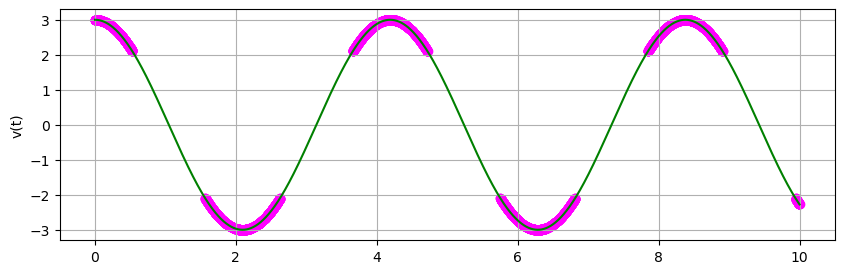

In [24]:
# Mely időszakaszokban ment a test gyorsabban, mint a maximális sebességnagyság 70%-a?
# Jelenítsük ezt meg a grafikonon!

# sebesség abszolútértéke érdekes:
v_abs=np.abs(v) 
v_abs_max=v_abs.max()
map_fast=v_abs>v_abs_max*0.7
t_fast=t[map_fast]

fig=plt.figure(figsize=(10,3))  
ax1=fig.add_subplot(111) 
ax1.set_ylabel("v(t)")
ax1.plot(t, v, color="green")
ax1.scatter(t_fast, v[map_fast], color="magenta")
ax1.grid()

In [25]:
# Mennyi ideig haladt a test 'gyorsan'?

sum_t_fast=integ(t, map_fast*1.0)[-1]
print(f"A test ennyi ideig haladt 'gyorsan': {sum_t_fast:.3f} s.")

A test ennyi ideig haladt 'gyorsan': 4.830 s.


In [26]:
# A gyors szakaszok össz útja

dx_abs=np.append(np.abs(np.diff(x)), [0])  # lépések az intervallumokban
fast_steps=dx_abs*map_fast
sum_fast_steps=fast_steps.sum()
print(f"A 'gyors' szakaszokon megtett össz út: {sum_fast_steps:.3} m.")

A 'gyors' szakaszokon megtett össz út: 13.0 m.


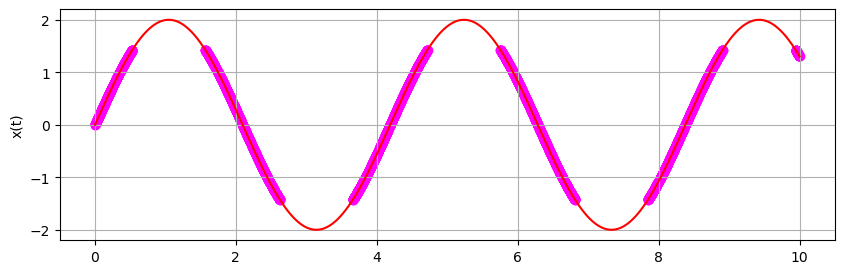

In [27]:
# Amikor a test gyorsan ment, akkor mi volt az 'x' koordinátája? Ábrázolja grafikonon!

fig=plt.figure(figsize=(10,3))  
ax1=fig.add_subplot(111) 
ax1.set_ylabel("x(t)")
ax1.plot(t, x, color="red")
ax1.scatter(t_fast, x[map_fast], color="magenta")
ax1.grid()

## Önálló feladatok

**1. feladat:** 

Az előző rezgéses példában:

   * A vizsgált időszak hány százaléka alatt volt a sebesség nagysága nagyobb, mint 1.0 m/s?
   * A vizsgált időszak hány százaléka alatt volt a sebesség nagysága nagyobb, mint a maximális sebesség fele?
   * Amíg a test a maximális sebesség felénél nagyobb sebességgel ment, addig mennyi volt az általa megtett össz út?
   

**2. feladat:**

Az előző rezgéses példában:

   * Mely időpontokban volt a test az origóban?
   * Hány ilyen időpont volt?
   * Mi volt ezen időpontokban a sebességének értéke?
   * Jelölje ezeket a pontokat az x(t) és v(t) grafikonokon is!

**3. feladat:**

Egy testet 5 m magasról, 15 m/s kezdősebességgel felfelé dobunk.

   * Mekkora lesz a test legnagyobb magassága és mikor következik ez be?
   * Mikor és milyen sebességgel csapódik a földbe?
   * Mely időpontokban lesz a talajtól való távolsága 10 m?
   * Az előző időpontok melyikében halad felfelé a test? (Számolja ki, ne csak a grafikonról olvassa le!)
   * Mennyi ideig tartózkodik 10 m-nél magasabban és ez alatt mennyi az össz megtett útja?

**4. feladat:**

Az `openclose` függvény esetén az `A=0.024; t0=0.01; width=0.0045` paraméterek mellett:
   * Rajzolja ki a hely, sebesség és gyorsulás adatokat az idő függvényében 0 és 0.02 s között.
   * Mennyi ideig nagyobb a szelep nyitása, mint a maximális érték 90%-a? (Azaz mennyi ideig nagyobb `x`, mint `0.9 * A`?)
   * Mely időpontokban lesz a nyitás mértéke épp a maximális érték 90%-a?
   * Ezek közül melyik időpont az, amikor épp csukódik a szelep?
   * Mekkora a legnagyobb gyorsulás-abszolútérték a mozgás során?
   * "Nagy gyorsulású" időszaknak nevezzük azokat, amikor a gyorsulás abszolút értéke nagyobb, mint a maximális gyorsulás 80%-a. Mennyi a nagy gyorsulású időszakaszok össz hossza?
   * Jelölje az x(t), v(t) és a(t) grafikonon is a nagy gyorsulású részeket!

## Új NumPy eljárások:

   * `aa.astype(newtype)`: `aa`-val egyező tartamú, de `newtype` típusú tömb
   * `np.argwhere(arr)`: azon indexek tömbje, ahol nemnulla numerikus vagy "True" boolean érték áll
   * `arr.flatten()`: sokdimenziós tömböt egydimenzióssá "vasal"
   * MatPlotLib `scatter()`: pontokat jelöl be a grafikonon
   
Fontos NumPy tudás: NumPy tömbre logikai kifejezést alkalmazva egy True/False térképet kapunk a logikai kifejezés teljesüléséről. Ezt 1/0 tömbbé alakíthatjuk matematikai művelettel, vagy az `.astype()` paranccsal. Ezzel adott tulajdonságú pályaszakaszokat válaszhatunk ki.